# SE-ActChain

The workflow is:
1. Prepare activity chain data
2. Pre-train activity type embeddings based on word2vec (CBOW)
3. Aggregate word embeddings to sentence embeddings using Smooth Inverse Frequency model

In [1]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

from pprint import pprint

# Configs

In [ ]:
city = "london"  # {"london", "singapore"}
str_study_period = "20250210_20250223"
loc_embed_type = "cbow"

if city == "london":
    proj_crs = "EPSG:27700"
elif city == "singapore":
    proj_crs = "EPSG:3414"

## Clustering config: almost all are default values suggested by BERTopic -- we do not tune them because it's not the focus of this work.
# These params are kept consistent across all models to ensure a fair comparison of the representation methods.
umap_config = {
    "n_neighbors": 30,  # Controls how UMAP balances local vs global structure (30-50 is good for 100k rows)
    "min_dist": 0.0,  # Set to 0.0 to pack points tightly together for better density clustering
    "n_components": 5,  # The dimensionality of the space to embed into. For visualization, 2 is common. For clustering, the default of 5 is a good starting point, but you can experiment with this.
    "metric": 'cosine',   # Cosine distance should be used for word embeddings-based features
    "random_state": 101  # For reproducibility
}

In [5]:
def get_data_dir_path(target_dir_str="mobility_data"):
    """
    Get data dir by seearching the current directory for the folder named 
    If there is no folder named {target_dir_str}, then search the parrent directory for it.
    Do this until a folder named {target_dir_str} is found or the root directory is reached
    """
    current_dir = os.getcwd()
    target_data_dir = None
    while True:
        if target_dir_str in os.listdir(current_dir):
            target_data_dir = os.path.join(current_dir, target_dir_str)
            break
        else:
            parent_dir = os.path.dirname(current_dir)
            if parent_dir == current_dir:  # Reached the root directory
                print(f"Error: Could not find a folder named '{target_dir_str}' in the current directory or any of its parent directories.")
                break
            current_dir = parent_dir
    return target_data_dir

## 1. Data Preparation

### 1.1. Load the stays (with sigplaces)

In [23]:
mobility_data_dir = get_data_dir_path("mobility_data")
mobility_data_file = f"{city}_{str_study_period}_stays_bbox_min2staysperday_with_sigplaces.csv.gz"
mobility_data_path = os.path.join(mobility_data_dir, mobility_data_file)
print(f"Loading mobility data from {mobility_data_path}...\n")

df_stays = pd.read_csv(mobility_data_path)
df_stays.head()

Loading mobility data from /home/xlwang/code/2026/ace_dev/mobility_data/london_20250210_20250223_stays_bbox_min2staysperday_with_sigplaces.csv.gz...



,user_id,start_time,end_time,longitude,latitude,significant_place
0,000088cc-b646-409b-a026-69cd9d47b838,2025-02-18 01:53:39,2025-02-18 11:08:27,-0.133369,51.323206,0
1,000088cc-b646-409b-a026-69cd9d47b838,2025-02-18 13:52:23,2025-02-18 14:45:13,-0.166586,51.481968,1
2,000088cc-b646-409b-a026-69cd9d47b838,2025-02-18 19:43:05,2025-02-18 22:53:39,-0.133383,51.323275,0
3,000088cc-b646-409b-a026-69cd9d47b838,2025-02-19 01:43:03,2025-02-19 10:49:59,-0.133407,51.323269,0
4,000088cc-b646-409b-a026-69cd9d47b838,2025-02-19 17:46:28,2025-02-19 22:43:03,-0.133356,51.323277,0


 ### 1.2. Load the POIs

In [ ]:
gis_data_dir = get_data_dir_path('gis_data')

In [ ]:
if city == 'london':
    print("Loading London POI data...\n")
    gdf_poi = gpd.read_file(f'/home/xlwang/data/poi/london_bbox_202503/poi_6405256/poi_6405256.gpkg')
    print(f"Number of unique Group: {gdf_poi['groupname'].nunique()}")
    print(f"Number of unique Category: {gdf_poi['categoryname'].nunique()}")
    print(f"Number of unique Class: {gdf_poi['classname'].nunique()}")

    # print(f"Number of self-defined semantics: {gdf_poi['semantics'].nunique()}")

    # gdf_bd_pseudo_poi = gpd.read_file(f'{gis_data_dir}/london_bd_pseudo_poi_sampled.geojson')
    # gdf_poi = pd.concat([gdf_poi, gdf_bd_pseudo_poi], ignore_index=True).drop(columns=['admin_boundary'])
    # print(f"Number of total POIs after adding BD pseudo POIs: {len(gdf_poi)}")

elif city == 'singapore':
    print("Loading Singapore POI data...\n")
    df_poi = pd.read_csv(f'{gis_data_dir}/sg_fsq_poi_cleaned.csv.gz', compression='gzip')
    print(f"Number of POIs: {len(df_poi)}")
    gdf_poi = gpd.GeoDataFrame(df_poi, geometry=gpd.points_from_xy(df_poi['longitude'], df_poi['latitude'], crs='EPSG:4326')).to_crs(proj_crs)
    gdf_poi['fsq_category_ids'] = gdf_poi['fsq_category_ids'].apply(lambda x: x[1:-1])
    # Explode categories in column fsq_category_ids into multiple rows
    gdf_poi['fsq_category_ids'] = gdf_poi['fsq_category_ids'].str.split(',')
    gdf_poi = gdf_poi.explode('fsq_category_ids').reset_index(drop=True)
    gdf_poi['fsq_category_ids'] = gdf_poi['fsq_category_ids'].str.strip()
    gdf_poi.rename(columns={'fsq_category_ids': 'fsq_category_id'}, inplace=True)
    print(f"Number of POIs after exploding categories: {len(gdf_poi)}")
    # Load fsq category mapping
    fsq_categories = pd.read_csv(f'{gis_data_dir}/fsq_categories.csv')
    fsq_categories = fsq_categories.rename(columns={'Category Name': 'fsq_category_name', 
                                                'Category ID': 'fsq_category_id'}).drop(columns=['Category Label'])
    gdf_poi = pd.merge(gdf_poi, fsq_categories, on='fsq_category_id', how='left')

### 1.3. Sigplaces and home

In [ ]:
sigplaces_home_dir = get_data_dir_path('sigplaces_and_home')

df_sigplaces = pd.read_csv(f"{sigplaces_home_dir}/{city}_{str_study_period}_sigplaces_with_home.csv.gz")
df_sigplaces

In [ ]:
gdf_sigplaces = gpd.GeoDataFrame(
    df_sigplaces, geometry=gpd.points_from_xy(df_sigplaces['cluster_x'], df_sigplaces['cluster_y']), crs="EPSG:27700"
)
# 150m buffer around significant places to define the area of interest for nearby POIs
gdf_sigplaces['geometry'] = gdf_sigplaces.geometry.buffer(150)

# Sjoin to get list of POIs around each significant places
gdf_sigplaces_poi = gpd.sjoin(gdf_sigplaces, gdf_poi, how='left', predicate='within')

# Get the POIs around the significant places by spatial join
gdf_sigplaces_poi = gpd.sjoin(gdf_sigplaces, gdf_poi, how='left', predicate='contains')
# Drop the rows with missing POI information (i.e., no POI around the significant place)
print(f"Number of rows that have NaN in index_right (i.e., no POI around the significant place): {gdf_sigplaces_poi['index_right'].isna().sum()}")
# gdf_sigplaces_poi = gdf_sigplaces_poi.dropna(subset=['index_right'])
print(f"We do not drop these rows; we might look into these significant places without POIs around them later.")

# Separate sig places with and without POIs around them
gdf_sigplaces_poi_with_poi = gdf_sigplaces_poi[~gdf_sigplaces_poi['index_right'].isna()]
gdf_sigplaces_poi_without_poi = gdf_sigplaces_poi[gdf_sigplaces_poi['index_right'].isna()]
print(f"Num of sig places with pois around them: {len(gdf_sigplaces_poi_with_poi)}")
print(f"Num of sig places without pois around them: {len(gdf_sigplaces_poi_without_poi)}")

gdf_sigplaces_poi_without_poi = gdf_sigplaces_poi_without_poi[['user_id', 'significant_place', 'cluster_x', 'cluster_y', 'is_home']]
gdf_sigplaces_poi_without_poi['list_groupname'] = np.nan

# Get the list of POIs around each significant place
df_sigplaces_poi_list = gdf_sigplaces_poi_with_poi.groupby(['user_id', 'significant_place'], 
                                                  as_index=False).agg({'groupname': list,
                                                                       'cluster_x': 'first',
                                                                       'cluster_y': 'first',
                                                                       'is_home': 'first'
                                                                       }).rename(columns={'groupname': 'list_groupname'})

df_sigplaces_poi_list

# This would run for almost 3.5 minutes on timecore.

In [ ]:
# Concatenate the sig places with and without POIs around them back together
df_sigplaces_poi_list = pd.concat([df_sigplaces_poi_list, gdf_sigplaces_poi_without_poi], ignore_index=True)
df_sigplaces_poi_list = df_sigplaces_poi_list.sort_values(by=['user_id', 'significant_place']).reset_index(drop=True)
df_sigplaces_poi_list

In [ ]:
df_sigplaces_poi_list.loc[0, 'list_groupname']

In [ ]:
df_sigplaces_poi_list.info()

In [ ]:
df_sigplaces_poi_list['is_home'] == True

### Get the deterministic semantic type for each sig place
Each significant place is associated with an activity type

In [ ]:
from gensim.corpora import Dictionary
from gensim.models import TfidfModel

def infer_activity_types(df):
    """
    Takes the significant places dataframe and applies an enhanced TF-IDF 
    model to categorise non-home stay points.
    """
    # 1. Isolate the non-home locations to be inferred
    # (Assuming work locations are either handled separately or mixed in here)
    if 'inferred_activity' not in df.columns:
        df['inferred_activity'] = pd.Series(pd.NA, index=df.index, dtype='object')
    else:
        df['inferred_activity'] = df['inferred_activity'].astype('object')

    home_mask = df['is_home'].eq(True)
    mask_to_infer = ~home_mask
    df_infer = df[mask_to_infer].copy()
    
    # Extract the POI lists (ensure we handle any potential nulls/NaNs)
    poi_lists = df_infer['list_groupname'].apply(
        lambda x: x if isinstance(x, list) else []
    ).tolist()

    # 2. Build the Gensim Dictionary and Corpus (Bag of Words)
    dictionary = Dictionary(poi_lists)
    corpus = [dictionary.doc2bow(text) for text in poi_lists]

    # 3. Train the TF-IDF model on our spatial corpus
    tfidf = TfidfModel(corpus)

    # 4. Define the Enhanced Selection Logic
    def get_best_poi_category(bow, tfidf_vector, dictionary, min_support=2, dense_threshold=5):
        if not bow:
            return "Other" # No POIs captured in the 150m buffer
            
        # Create a quick lookup dictionary for raw Term Frequencies (TF)
        tf_dict = {dictionary[idx]: count for idx, count in bow}
        total_pois = sum(tf_dict.values())
        
        # Sort the TF-IDF vector by score, descending
        sorted_tfidf = sorted(tfidf_vector, key=lambda x: x[1], reverse=True)
        
        for idx, score in sorted_tfidf:
            category = dictionary[idx]
            raw_count = tf_dict[category]
            
            # The Enhancement: Prevent the "Rare POI" anomaly.
            # If the area is dense, a category must appear more than once to win.
            if total_pois >= dense_threshold and raw_count < min_support:
                continue 
                
            return category
            
        # Fallback: If the threshold filters out all TF-IDF candidates,
        # simply return the category with the highest raw count.
        return max(tf_dict, key=tf_dict.get)

    # 5. Apply the logic to generate the final activity labels
    inferred_activities = []
    for bow in corpus:
        tfidf_vec = tfidf[bow]
        best_category = get_best_poi_category(bow, tfidf_vec, dictionary)
        inferred_activities.append(best_category)

    # Assign the results back to the dataframe
    df_infer['inferred_activity'] = inferred_activities
    
    # Merge the inferred activities back into the original dataframe
    # Home locations will naturally have NaN or 'Home' depending on your setup
    df.loc[mask_to_infer, 'inferred_activity'] = df_infer['inferred_activity']
    df.loc[home_mask, 'inferred_activity'] = 'Home'
    
    return df

# Example Execution
# df_sigplaces_poi_list = infer_activity_types(df_sigplaces_poi_list)

In [ ]:
df_sigplaces_with_det_sem = infer_activity_types(df_sigplaces_poi_list)
df_sigplaces_with_det_sem

# This would run for almost 24 seconds on timecore.

In [24]:
# # Save to local
# df_sigplaces_with_det_sem.to_csv(f'./{city}_sigplaces_with_inferred_activity.csv.gz', index=False, compression='gzip')

# Load from local if necessary
df_sigplaces_with_det_sem = pd.read_csv(f'./{city}_sigplaces_with_inferred_activity.csv.gz', compression='gzip')
if "list_groupname" in df_sigplaces_with_det_sem.columns:
    df_sigplaces_with_det_sem.drop(columns=['list_groupname'], inplace=True)
if "is_home" in df_sigplaces_with_det_sem.columns:
    df_sigplaces_with_det_sem.drop(columns=['is_home'], inplace=True)

df_sigplaces_with_det_sem
# The final columns: [user_id, significant_place, cluster_x, cluster_y, inferred_activity]

,user_id,significant_place,cluster_x,cluster_y,inferred_activity
0,000088cc-b646-409b-a026-69cd9d47b838,0,530161.650419,159894.898575,Home
1,000088cc-b646-409b-a026-69cd9d47b838,1,527406.321829,177483.676174,Attractions
2,0000c7af-c002-4e39-ad0e-975c01dbe25e,0,553352.580561,182964.732347,Home
3,0000c7af-c002-4e39-ad0e-975c01dbe25e,1,553875.110693,182649.901302,Transport
4,000135bd-bf0b-4880-af99-1791ce98dddf,0,521030.394811,168403.307828,Home
...,...,...,...,...,...
937808,ffff8ebb-33d5-4851-a36d-12de4548ea2e,7,535298.958350,191977.129395,Retail
937809,ffff8ebb-33d5-4851-a36d-12de4548ea2e,8,534199.999362,191917.508375,Commercial Services
937810,ffff8ebb-33d5-4851-a36d-12de4548ea2e,9,532805.730369,196302.510275,Retail
937811,ffff8ebb-33d5-4851-a36d-12de4548ea2e,10,536249.589648,185336.063915,Attractions


In [8]:
df_stays.info()

<class 'pandas.DataFrame'>
RangeIndex: 3498979 entries, 0 to 3498978
Data columns (total 6 columns):
 #   Column             Dtype  
---  ------             -----  
 0   user_id            str    
 1   start_time         str    
 2   end_time           str    
 3   longitude          float64
 4   latitude           float64
 5   significant_place  int64  
dtypes: float64(2), int64(1), str(3)
memory usage: 407.1 MB


In [25]:
# Merge with df_stays
df_stays = pd.merge(df_stays, df_sigplaces_with_det_sem[['user_id', 'significant_place', 'inferred_activity']], 
                    on=['user_id', 'significant_place'], how='left')

# Get the time indices for each stay with 30 minutes as the interval, e.g., 00:00-00:29 -> 0, 00:30-00:59 -> 1, ..., 23:30-23:59 -> 47
df_stays['start_time'] = pd.to_datetime(df_stays['start_time'])
df_stays['start_time_index'] = df_stays['start_time'].dt.hour * 2 + df_stays['start_time'].dt.minute // 30
df_stays['end_time'] = pd.to_datetime(df_stays['end_time'])
df_stays['end_time_index'] = df_stays['end_time'].dt.hour * 2 + df_stays['end_time'].dt.minute // 30

df_stays['date'] = df_stays['start_time'].dt.date

df_stays['active_time_indices'] = df_stays.apply(lambda row: list(range(row['start_time_index'], row['end_time_index'] + 1)), axis=1)
# Explode the active_time_indices into multiple rows
df_stays = df_stays.explode('active_time_indices').reset_index(drop=True).rename(columns={'active_time_indices': 'time_index'})

df_stays

,user_id,start_time,end_time,longitude,latitude,significant_place,inferred_activity,start_time_index,end_time_index,date,time_index
0,000088cc-b646-409b-a026-69cd9d47b838,2025-02-18 01:53:39,2025-02-18 11:08:27,-0.133369,51.323206,0,Home,3,22,2025-02-18,3
1,000088cc-b646-409b-a026-69cd9d47b838,2025-02-18 01:53:39,2025-02-18 11:08:27,-0.133369,51.323206,0,Home,3,22,2025-02-18,4
2,000088cc-b646-409b-a026-69cd9d47b838,2025-02-18 01:53:39,2025-02-18 11:08:27,-0.133369,51.323206,0,Home,3,22,2025-02-18,5
3,000088cc-b646-409b-a026-69cd9d47b838,2025-02-18 01:53:39,2025-02-18 11:08:27,-0.133369,51.323206,0,Home,3,22,2025-02-18,6
4,000088cc-b646-409b-a026-69cd9d47b838,2025-02-18 01:53:39,2025-02-18 11:08:27,-0.133369,51.323206,0,Home,3,22,2025-02-18,7
...,...,...,...,...,...,...,...,...,...,...,...
29513499,ffff8ebb-33d5-4851-a36d-12de4548ea2e,2025-02-23 13:00:26,2025-02-23 23:40:27,-0.045168,51.624577,0,Home,26,47,2025-02-23,43
29513500,ffff8ebb-33d5-4851-a36d-12de4548ea2e,2025-02-23 13:00:26,2025-02-23 23:40:27,-0.045168,51.624577,0,Home,26,47,2025-02-23,44
29513501,ffff8ebb-33d5-4851-a36d-12de4548ea2e,2025-02-23 13:00:26,2025-02-23 23:40:27,-0.045168,51.624577,0,Home,26,47,2025-02-23,45
29513502,ffff8ebb-33d5-4851-a36d-12de4548ea2e,2025-02-23 13:00:26,2025-02-23 23:40:27,-0.045168,51.624577,0,Home,26,47,2025-02-23,46


In [ ]:
pprint(df_stays['inferred_activity'].unique().tolist())

# Modelling

In [ ]:
from gensim.models import Word2Vec
from sklearn.decomposition import TruncatedSVD
from collections import Counter
import pickle

In [ ]:
def construct_daily_activity_corpus(
    df_stays,
    user_col='user_id',
    date_col='date',
    time_col='time_index',
    activity_col='inferred_activity',
):
    """
    Constructs one 48-word daily activity chain for each user-day.

    Returns a daily_chain_index DataFrame with one row per (user_id, date):
    - user_id
    - date
    - daily_activity_chain
    - day_type: weekday or weekend

    The row order of daily_chain_index is the alignment key for daily embeddings.
    """
    df = df_stays.copy()
    df = df.drop_duplicates(subset=[user_col, date_col, time_col], keep='last')
    df[activity_col] = df[activity_col].fillna('Unknown').astype(str)

    df_pivot = df.pivot(index=[user_col, date_col], columns=time_col, values=activity_col)
    df_pivot = df_pivot.reindex(columns=range(48)).fillna('Unknown')

    daily_chain_index = df_pivot.reset_index()
    chain_cols = list(range(48))
    daily_chain_index['daily_activity_chain'] = daily_chain_index[chain_cols].apply(
        lambda row: [f"{time_index}_{activity}" for time_index, activity in row.items()],
        axis=1,
    )
    daily_chain_index = daily_chain_index[[user_col, date_col, 'daily_activity_chain']]

    date_values = pd.to_datetime(daily_chain_index[date_col])
    daily_chain_index['day_type'] = np.where(date_values.dt.dayofweek < 5, 'weekday', 'weekend')

    return daily_chain_index

In [ ]:
class SEActivityChainEmbedder:
    """
    Learns dense numerical representations (embeddings) for daily human mobility chains 
    using a CBOW Word2Vec model and Smooth Inverse Frequency (SIF) weighting.
    """
    
    def __init__(self, vector_size=20, window_size=3, sif_weighting_param=0.0001):
        """
        Initialise the embedder.
        
        Parameters:
        - vector_size: Dimensionality of the word vectors (default: 20).
        - window_size: Context window for CBOW. Defaulted to 3 (1.5 hours) for daily chains.
        - sif_weighting_param: 'a' parameter for SIF weighting (default: 0.0001).
        """
        self.vector_size = vector_size
        self.window_size = window_size
        self.a = sif_weighting_param
        
        self.word2vec_model = None
        self.word_probabilities = {}
        self.first_singular_vector = None 

    def _train_word_embeddings(self, corpus):
        """
        Trains the CBOW model to learn representations for individual activity units.
        """
        self.word2vec_model = Word2Vec(
            sentences=corpus, 
            vector_size=self.vector_size, 
            window=self.window_size, 
            sg=0,  # CBOW
            min_count=1, 
            workers=4
        )

    def _calculate_word_frequencies(self, corpus):
        """
        Computes the global frequency probability p(w) for each activity unit across the dataset.
        """
        word_counts = Counter()
        total_words = 0
        for chain in corpus:
            word_counts.update(chain)
            total_words += len(chain)
            
        self.word_probabilities = {
            word: count / total_words for word, count in word_counts.items()
        }

    def _compute_sentence_embeddings(self, corpus):
        """
        Aggregates unit vectors into a single daily chain vector using SIF weighting.
        """
        sentence_embeddings = []
        for chain in corpus:
            vs = np.zeros(self.vector_size)
            valid_words = 0
            
            for word in chain:
                if word in self.word2vec_model.wv:
                    vw = self.word2vec_model.wv[word]
                    pw = self.word_probabilities[word]
                    
                    # SIF Weighting formula: a / (a + p(w))
                    weight = self.a / (self.a + pw)
                    vs += weight * vw
                    valid_words += 1
                    
            if valid_words > 0:
                vs = vs / len(chain) 
                
            sentence_embeddings.append(vs)
            
        return np.array(sentence_embeddings)

    def _remove_first_principal_component(self, embeddings):
        """
        Removes the first singular vector to isolate unique behavioural patterns.
        """
        svd = TruncatedSVD(n_components=1, n_iter=7, random_state=42)
        svd.fit(embeddings)
        self.first_singular_vector = svd.components_[0]
        
        projection = embeddings.dot(self.first_singular_vector.transpose())
        projection_matrix = np.outer(projection, self.first_singular_vector)
        
        return embeddings - projection_matrix

    def fit_transform(self, activity_chains):
        """
        Orchestrates the entire pipeline from raw string chains to final embeddings.
        """
        self._train_word_embeddings(activity_chains)
        self._calculate_word_frequencies(activity_chains)
        embeddings = self._compute_sentence_embeddings(activity_chains)
        final_embeddings = self._remove_first_principal_component(embeddings)
        
        return final_embeddings

In [ ]:
# Construct one shared user-day index; derive weekday/weekend corpora from it later.
daily_chain_index = construct_daily_activity_corpus(df_stays)

print(f"Total daily activity chains: {len(daily_chain_index)}")
print(f"Total users with daily activity chains: {daily_chain_index['user_id'].nunique()}")

for day_type, day_index in daily_chain_index.groupby('day_type', sort=False):
    print(f"{day_type}: {len(day_index)} daily activity chains")
    print(f"{day_type}: {day_index['user_id'].nunique()} users")
    if not day_index.empty:
        print(f"{day_type}: {len(day_index.iloc[0]['daily_activity_chain'])} slots per daily chain")  # Should be 48

In [ ]:
df_stays['user_id'].nunique()

In [ ]:
def fit_save_and_aggregate_user_activity_embeddings(
    day_type,
    daily_chain_index,
    model_output_dir,
    user_col='user_id',
    date_col='date',
    chain_col='daily_activity_chain',
    vector_size=20,
    window_size=3,
    sif_weighting_param=0.0001,
):
    """
    Fits one SE-ActChain embedder for a day type and aggregates daily chain
    embeddings into user-level activity-pattern embeddings.
    """
    day_chain_index = (
        daily_chain_index[daily_chain_index['day_type'] == day_type]
        .reset_index(drop=True)
        .copy()
    )
    if day_chain_index.empty:
        raise ValueError(f"No daily activity chains available for {day_type}.")

    corpus = day_chain_index[chain_col].tolist()
    if not all(len(chain) == 48 for chain in corpus):
        raise ValueError(f"Expected all {day_type} daily activity chains to have 48 time slots.")

    embedder = SEActivityChainEmbedder(
        vector_size=vector_size,
        window_size=window_size,
        sif_weighting_param=sif_weighting_param,
    )
    daily_chain_embeddings = embedder.fit_transform(corpus)

    os.makedirs(model_output_dir, exist_ok=True)
    model_path = os.path.join(model_output_dir, f"se_act_chain_{day_type}_embedder.pkl")
    with open(model_path, "wb") as f:
        pickle.dump(embedder, f)

    embedding_cols = [f"se_act_chain_{day_type}_{i}" for i in range(daily_chain_embeddings.shape[1])]
    daily_chain_embedding_df = pd.concat(
        [
            day_chain_index[[user_col, date_col, 'day_type']].reset_index(drop=True),
            pd.DataFrame(daily_chain_embeddings, columns=embedding_cols),
        ],
        axis=1,
    )

    user_activity_embedding_df = daily_chain_embedding_df.groupby(user_col)[embedding_cols].mean()
    user_activity_embeddings = {
        user_id: row.to_numpy()
        for user_id, row in user_activity_embedding_df.iterrows()
    }

    return {
        'day_type': day_type,
        'corpus': corpus,
        'embedder': embedder,
        'model_path': model_path,
        'daily_chain_embeddings': daily_chain_embeddings,
        'daily_chain_embedding_df': daily_chain_embedding_df,
        'user_activity_embeddings': user_activity_embeddings,
        'user_activity_embedding_df': user_activity_embedding_df,
    }


model_output_dir = os.path.join('pretrained_se_act_chain', f'{city}_{str_study_period}')
day_types = ['weekday', 'weekend']
se_act_chain_results = {
    day_type: fit_save_and_aggregate_user_activity_embeddings(
        day_type,
        daily_chain_index,
        model_output_dir,
        vector_size=20,
        window_size=3,
    )
    for day_type in day_types
}

weekday_results = se_act_chain_results['weekday']
weekend_results = se_act_chain_results['weekend']

weekday_training_corpus = weekday_results['corpus']
weekend_training_corpus = weekend_results['corpus']
weekday_embedder = weekday_results['embedder']
weekend_embedder = weekend_results['embedder']
weekday_daily_chain_embeddings = weekday_results['daily_chain_embeddings']
weekend_daily_chain_embeddings = weekend_results['daily_chain_embeddings']
weekday_daily_chain_embedding_df = weekday_results['daily_chain_embedding_df']
weekend_daily_chain_embedding_df = weekend_results['daily_chain_embedding_df']
weekday_user_activity_embeddings = weekday_results['user_activity_embeddings']
weekend_user_activity_embeddings = weekend_results['user_activity_embeddings']
weekday_user_activity_embedding_df = weekday_results['user_activity_embedding_df']
weekend_user_activity_embedding_df = weekend_results['user_activity_embedding_df']

for day_type, results in se_act_chain_results.items():
    print(f"{day_type.capitalize()} training corpus: {len(results['corpus'])} daily chains")
    print(f"{day_type.capitalize()} daily chain embeddings: {results['daily_chain_embeddings'].shape}")
    print(f"{day_type.capitalize()} user activity embeddings: {results['user_activity_embedding_df'].shape}")
    print(f"Saved {day_type} model to: {results['model_path']}")

# Clustering

Use UMAP for dimensionality reduction and H-DBSCAN for clustering

In [ ]:
import gc
import umap
from sklearn.cluster import HDBSCAN
from hdbscan.validity import validity_index

In [ ]:
# UMAP reduces each user activity-pattern embedding from 20D to 5D for clustering.
umap_clustering_config = {
    'n_neighbors': 30,
    'min_dist': 0.0,
    'n_components': 5,
    'metric': 'cosine',
    'random_state': 101,
}

hdbscan_params_combinations = [
    {'min_cluster_size': 1000, 'min_samples': 30},
    {'min_cluster_size': 1000, 'min_samples': 50},
    {'min_cluster_size': 1000, 'min_samples': 100},
    {'min_cluster_size': 1000, 'min_samples': 200},
    {'min_cluster_size': 1000, 'min_samples': 300},
    {'min_cluster_size': 1000, 'min_samples': 500},
    {'min_cluster_size': 1000, 'min_samples': 1000},
    {'min_cluster_size': 2000, 'min_samples': 30},
    {'min_cluster_size': 2000, 'min_samples': 50},
    {'min_cluster_size': 2000, 'min_samples': 100},
    {'min_cluster_size': 2000, 'min_samples': 200},
    {'min_cluster_size': 2000, 'min_samples': 500},
    {'min_cluster_size': 2000, 'min_samples': 1000},
    {'min_cluster_size': 2000, 'min_samples': 2000},
]

# DBCV is higher when clusters are denser and better separated.
dbcv_metric = 'euclidean'
# Exact full-data DBCV can be slow. Use None for exact, or e.g. 30000 for a sampled score.
dbcv_sample_size = 30000
dbcv_random_state = umap_clustering_config['random_state']

clustering_output_dir = os.path.join(model_output_dir, 'clustering')
os.makedirs(clustering_output_dir, exist_ok=True)

In [ ]:
def _make_dbcv_score_subset(labels, sample_size=dbcv_sample_size, random_state=dbcv_random_state):
    if sample_size is None or sample_size >= len(labels):
        return np.arange(len(labels))
    rng = np.random.default_rng(random_state)
    return np.sort(rng.choice(len(labels), size=sample_size, replace=False))


def reduce_user_embeddings_with_umap(day_type, user_activity_embedding_df, output_dir):
    embedding_cols = user_activity_embedding_df.columns.tolist()
    input_embedding = user_activity_embedding_df[embedding_cols].to_numpy(dtype=np.float32)
    input_dim = input_embedding.shape[1]
    n_components = umap_clustering_config['n_components']

    umap_embedding_path = os.path.join(
        output_dir,
        f'se_act_chain_{day_type}_umap{n_components}d.npz',
    )
    if os.path.exists(umap_embedding_path):
        umap_embedding = np.load(umap_embedding_path)['embedding']
        print(f'{day_type}: loaded {n_components}D UMAP embedding from {umap_embedding_path}')
    else:
        reducer = umap.UMAP(**umap_clustering_config)
        umap_embedding = reducer.fit_transform(input_embedding)
        np.savez_compressed(
            umap_embedding_path,
            embedding=umap_embedding,
            user_id=user_activity_embedding_df.index.to_numpy(),
            source_embedding_columns=np.array(embedding_cols),
        )
        print(f'{day_type}: saved {input_dim}D -> {n_components}D UMAP embedding to {umap_embedding_path}')

    umap_cols = [f'umap_{i}' for i in range(n_components)]
    umap_embedding_df = pd.DataFrame(
        umap_embedding,
        index=user_activity_embedding_df.index,
        columns=umap_cols,
    )
    umap_embedding_df.index.name = 'user_id'
    return umap_embedding_df, umap_embedding_path


def evaluate_hdbscan_dbcv(embedding, params):
    min_cluster_size = params['min_cluster_size']
    min_samples = params['min_samples']
    print(f'Evaluating min_cluster_size={min_cluster_size}, min_samples={min_samples}...')

    clusterer = HDBSCAN(
        min_cluster_size=min_cluster_size,
        min_samples=min_samples,
        metric=dbcv_metric,
    ).fit(embedding)

    labels = clusterer.labels_
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_outliers = np.count_nonzero(labels == -1)
    proportion_outliers = n_outliers / len(labels)

    if n_clusters < 2:
        dbcv_score = np.nan
        dbcv_error = 'DBCV requires at least two non-noise clusters'
        score_n_users = 0
    else:
        score_idx = _make_dbcv_score_subset(labels)
        score_embedding = np.asarray(embedding[score_idx], dtype=np.float64)
        score_labels = labels[score_idx]
        score_n_clusters = len(set(score_labels)) - (1 if -1 in score_labels else 0)
        score_n_users = len(score_idx)
        if score_n_clusters < 2:
            dbcv_score = np.nan
            dbcv_error = 'DBCV sample has fewer than two non-noise clusters'
        else:
            try:
                dbcv_score = validity_index(score_embedding, score_labels, metric=dbcv_metric)
                dbcv_error = None
            except Exception as exc:
                dbcv_score = np.nan
                dbcv_error = repr(exc)

    # scikit-learn's HDBSCAN does not expose cluster_persistence_.
    mean_cluster_persistence = np.nan

    result = {
        'min_cluster_size': min_cluster_size,
        'min_samples': min_samples,
        'num_clusters': n_clusters,
        'num_outliers': n_outliers,
        'proportion_outliers': proportion_outliers,
        'dbcv_score': dbcv_score,
        'dbcv_sample_size': dbcv_sample_size,
        'dbcv_scored_users': score_n_users,
        'mean_cluster_persistence': mean_cluster_persistence,
        'dbcv_error': dbcv_error,
    }
    print(
        f'DBCV={dbcv_score:.4f} | clusters={n_clusters} | outliers={n_outliers} ({proportion_outliers:.2%})'
        if np.isfinite(dbcv_score)
        else f'DBCV=nan | clusters={n_clusters} | error={dbcv_error}'
    )
    return result

In [ ]:
def cluster_user_activity_embeddings(day_type, user_activity_embedding_df, output_dir):
    umap_embedding_df, umap_embedding_path = reduce_user_embeddings_with_umap(
        day_type,
        user_activity_embedding_df,
        output_dir,
    )
    embedding = umap_embedding_df.to_numpy(dtype=np.float64)

    dbcv_rows = []
    for params in hdbscan_params_combinations:
        dbcv_rows.append(evaluate_hdbscan_dbcv(embedding, params))
        gc.collect()

    df_hdbscan_dbcv = pd.DataFrame(dbcv_rows).sort_values(
        by=['dbcv_score', 'proportion_outliers'],
        ascending=[False, True],
        na_position='last',
    )
    dbcv_summary_path = os.path.join(
        output_dir,
        f'hdbscan_dbcv_summary_se_act_chain_{day_type}_umap{umap_clustering_config["n_components"]}d.csv',
    )
    df_hdbscan_dbcv.to_csv(dbcv_summary_path, index=False)

    valid_dbcv = df_hdbscan_dbcv.dropna(subset=['dbcv_score'])
    if valid_dbcv.empty:
        raise ValueError(f'No valid DBCV score found for {day_type}. Check the parameter grid or embeddings.')

    best_params = valid_dbcv.iloc[0][['min_cluster_size', 'min_samples']].astype(int).to_dict()
    best_clusterer = HDBSCAN(
        min_cluster_size=best_params['min_cluster_size'],
        min_samples=best_params['min_samples'],
        metric=dbcv_metric,
    ).fit(embedding)

    cluster_col = (
        f'clst_se_act_chain_{day_type}_umap{umap_clustering_config["n_components"]}d_'
        f'size{best_params["min_cluster_size"]}_sample{best_params["min_samples"]}'
    )
    clustering_result_df = umap_embedding_df.reset_index()
    clustering_result_df[cluster_col] = best_clusterer.labels_

    clustering_result_path = os.path.join(
        output_dir,
        f'user_clustering_results_se_act_chain_{day_type}.csv',
    )
    clustering_result_df.to_csv(clustering_result_path, index=False)

    clusterer_path = os.path.join(
        output_dir,
        f'hdbscan_se_act_chain_{day_type}_umap{umap_clustering_config["n_components"]}d_'
        f'size{best_params["min_cluster_size"]}_sample{best_params["min_samples"]}.pkl',
    )
    with open(clusterer_path, 'wb') as f:
        pickle.dump(best_clusterer, f)

    n_clusters = len(set(best_clusterer.labels_)) - (1 if -1 in best_clusterer.labels_ else 0)
    n_outliers = np.count_nonzero(best_clusterer.labels_ == -1)
    print(f'{day_type}: DBCV summary saved to {dbcv_summary_path}')
    print(f'{day_type}: best params = {best_params}')
    print(f'{day_type}: {n_clusters} clusters, {n_outliers} outliers ({n_outliers / len(best_clusterer.labels_):.2%})')
    print(f'{day_type}: clustering results saved to {clustering_result_path}')
    print(f'{day_type}: HDBSCAN model saved to {clusterer_path}')

    return {
        'day_type': day_type,
        'umap_embedding_df': umap_embedding_df,
        'umap_embedding_path': umap_embedding_path,
        'dbcv_summary_df': df_hdbscan_dbcv,
        'dbcv_summary_path': dbcv_summary_path,
        'best_params': best_params,
        'clusterer': best_clusterer,
        'clusterer_path': clusterer_path,
        'cluster_col': cluster_col,
        'clustering_result_df': clustering_result_df,
        'clustering_result_path': clustering_result_path,
    }

In [ ]:
se_act_chain_clustering_results = {
    'weekday': cluster_user_activity_embeddings(
        'weekday',
        weekday_user_activity_embedding_df,
        clustering_output_dir,
    ),
    'weekend': cluster_user_activity_embeddings(
        'weekend',
        weekend_user_activity_embedding_df,
        clustering_output_dir,
    ),
}

weekday_clustering_results = se_act_chain_clustering_results['weekday']
weekend_clustering_results = se_act_chain_clustering_results['weekend']
weekday_user_clustering_df = weekday_clustering_results['clustering_result_df']
weekend_user_clustering_df = weekend_clustering_results['clustering_result_df']
weekday_hdbscan_dbcv_df = weekday_clustering_results['dbcv_summary_df']
weekend_hdbscan_dbcv_df = weekend_clustering_results['dbcv_summary_df']

for day_type, results in se_act_chain_clustering_results.items():
    print(f"{day_type}: retained column {results['cluster_col']}")
    print(results['dbcv_summary_df'].head())

# Analysis

Visualisation and interpretation of the clustering results.

In [2]:
weekday_clustering_res_path = 'pretrained_se_act_chain/london_20250210_20250223/clustering/user_clustering_results_se_act_chain_weekday.csv'
clst_res_col_name = "clst_se_act_chain_weekday_umap5d_size1000_sample200"


weekday_clustering_res = pd.read_csv(weekday_clustering_res_path)
weekday_clustering_res[clst_res_col_name].value_counts()

clst_se_act_chain_weekday_umap5d_size1000_sample200
 0    98819
 1     5163
-1      759
Name: count, dtype: int64

In [19]:
# Make the cluster id start from 1 instead of 0, and keep -1 for outliers.
weekday_clustering_res[clst_res_col_name] = weekday_clustering_res[clst_res_col_name].apply(lambda x: x + 1 if x != -1 else -1)
weekday_clustering_res[clst_res_col_name].value_counts()

clst_se_act_chain_weekday_umap5d_size1000_sample200
 1    98819
 2     5163
-1      759
Name: count, dtype: int64

In [21]:
weekday_clustering_res

,user_id,umap_0,umap_1,umap_2,umap_3,umap_4,clst_se_act_chain_weekday_umap5d_size1000_sample200
0,000088cc-b646-409b-a026-69cd9d47b838,9.942413,2.113105,8.486463,-0.730765,8.098234,1
1,000135bd-bf0b-4880-af99-1791ce98dddf,9.580240,3.248815,7.893205,-0.978815,7.109283,1
2,00016f95-edc9-4642-a6e6-70ce63b66346,10.282270,4.277446,8.633672,-0.805018,6.699747,1
3,0001dfff-15bc-404b-a5f2-a1ec0b458766,9.722697,3.512566,8.469083,0.078216,1.808536,1
4,00026b53-cb9f-4b07-aeb4-8e2aced6bb15,10.589106,2.483518,9.652382,0.975140,7.134463,1
...,...,...,...,...,...,...,...
104736,fffeb333-944f-4663-aea6-f310fe721d03,8.631476,1.894095,9.070940,0.093035,7.811041,1
104737,ffff1696-ce5a-499c-a567-1a9f612ca0c2,10.999448,6.473556,9.554668,0.002886,5.991141,1
104738,ffff1d0a-e065-451c-ab38-61d881dae01f,10.320915,3.238791,9.306982,4.308814,6.914818,1
104739,ffff2a7d-c1e9-4364-a074-59fc733599f6,8.996469,2.195368,8.227925,3.261861,7.549323,1


In [26]:
# First, get the original stays data -- user previous scripts to load and preprocess the data as needed.
df_stays

,user_id,start_time,end_time,longitude,latitude,significant_place,inferred_activity,start_time_index,end_time_index,date,time_index
0,000088cc-b646-409b-a026-69cd9d47b838,2025-02-18 01:53:39,2025-02-18 11:08:27,-0.133369,51.323206,0,Home,3,22,2025-02-18,3
1,000088cc-b646-409b-a026-69cd9d47b838,2025-02-18 01:53:39,2025-02-18 11:08:27,-0.133369,51.323206,0,Home,3,22,2025-02-18,4
2,000088cc-b646-409b-a026-69cd9d47b838,2025-02-18 01:53:39,2025-02-18 11:08:27,-0.133369,51.323206,0,Home,3,22,2025-02-18,5
3,000088cc-b646-409b-a026-69cd9d47b838,2025-02-18 01:53:39,2025-02-18 11:08:27,-0.133369,51.323206,0,Home,3,22,2025-02-18,6
4,000088cc-b646-409b-a026-69cd9d47b838,2025-02-18 01:53:39,2025-02-18 11:08:27,-0.133369,51.323206,0,Home,3,22,2025-02-18,7
...,...,...,...,...,...,...,...,...,...,...,...
29513499,ffff8ebb-33d5-4851-a36d-12de4548ea2e,2025-02-23 13:00:26,2025-02-23 23:40:27,-0.045168,51.624577,0,Home,26,47,2025-02-23,43
29513500,ffff8ebb-33d5-4851-a36d-12de4548ea2e,2025-02-23 13:00:26,2025-02-23 23:40:27,-0.045168,51.624577,0,Home,26,47,2025-02-23,44
29513501,ffff8ebb-33d5-4851-a36d-12de4548ea2e,2025-02-23 13:00:26,2025-02-23 23:40:27,-0.045168,51.624577,0,Home,26,47,2025-02-23,45
29513502,ffff8ebb-33d5-4851-a36d-12de4548ea2e,2025-02-23 13:00:26,2025-02-23 23:40:27,-0.045168,51.624577,0,Home,26,47,2025-02-23,46


In [27]:
useful_cols = ['user_id', 'date', 'time_index', 'inferred_activity']

df_stays = df_stays[useful_cols]

# Get the day-of-week
df_stays['date'] = pd.to_datetime(df_stays['date'])
df_stays['dow'] = df_stays['date'].dt.dayofweek

df_stays = pd.merge(df_stays, weekday_clustering_res[['user_id', clst_res_col_name]], on=['user_id'], how='left')
df_stays

,user_id,date,time_index,inferred_activity,dow,clst_se_act_chain_weekday_umap5d_size1000_sample200
0,000088cc-b646-409b-a026-69cd9d47b838,2025-02-18,3,Home,1,1.0
1,000088cc-b646-409b-a026-69cd9d47b838,2025-02-18,4,Home,1,1.0
2,000088cc-b646-409b-a026-69cd9d47b838,2025-02-18,5,Home,1,1.0
3,000088cc-b646-409b-a026-69cd9d47b838,2025-02-18,6,Home,1,1.0
4,000088cc-b646-409b-a026-69cd9d47b838,2025-02-18,7,Home,1,1.0
...,...,...,...,...,...,...
29513499,ffff8ebb-33d5-4851-a36d-12de4548ea2e,2025-02-23,43,Home,6,1.0
29513500,ffff8ebb-33d5-4851-a36d-12de4548ea2e,2025-02-23,44,Home,6,1.0
29513501,ffff8ebb-33d5-4851-a36d-12de4548ea2e,2025-02-23,45,Home,6,1.0
29513502,ffff8ebb-33d5-4851-a36d-12de4548ea2e,2025-02-23,46,Home,6,1.0


In [28]:
df_stays_weekday = df_stays[df_stays['dow'] < 5].copy()
df_stays_weekend = df_stays[df_stays['dow'] >= 5].copy()

In [29]:
ACTIVITY_ORDER = [
    "Accommodation, Eating and Drinking",
    "Commercial Services",
    "Attractions",
    "Sport and Entertainment",
    "Education and Health",
    "Public Infrastructure",
    "Manufacturing and Production",
    "Retail",
    "Transport",
    "Other",
]

ACTIVITY_LABELS = {
    "Accommodation, Eating and Drinking": "Accom, Eat and Drink",
    "Commercial Services": "Commercial",
    "Sport and Entertainment": "Sport and Ent",
    "Education and Health": "Edu and Health",
    "Public Infrastructure": "Public Infra",
    "Manufacturing and Production": "Manufacturing",
}


def get_ordered_activity_types(observed_activities, include_home=True, activity_order=ACTIVITY_ORDER):
    observed = [activity for activity in pd.Series(observed_activities).dropna().unique().tolist()]
    ordered = [activity for activity in activity_order if activity in observed or activity == 'Other']
    extras = sorted(activity for activity in observed if activity not in set(activity_order + ['Home']))

    if include_home and 'Home' in observed:
        return ['Home'] + ordered + extras
    return ordered + extras


cluster_ids = sorted(df_stays_weekday[clst_res_col_name].dropna().unique().tolist())
time_indices = list(range(48))
activity_types = get_ordered_activity_types(
    df_stays_weekday['inferred_activity'],
    include_home=True,
)

df_stays_weekday_to_plot = pd.MultiIndex.from_product(
    [cluster_ids, time_indices, activity_types],
    names=['cluster_id', 'time_index', 'inferred_activity'],
).to_frame(index=False)

df_stays_weekday_to_plot

,cluster_id,time_index,inferred_activity
0,-1.0,0,Home
1,-1.0,0,"Accommodation, Eating and Drinking"
2,-1.0,0,Commercial Services
3,-1.0,0,Attractions
4,-1.0,0,Sport and Entertainment
...,...,...,...
1579,2.0,47,Public Infrastructure
1580,2.0,47,Manufacturing and Production
1581,2.0,47,Retail
1582,2.0,47,Transport


In [30]:
weekday_activity_counts = (
    df_stays_weekday
    .groupby([clst_res_col_name, 'time_index', 'inferred_activity'])
    .size()
    .reset_index(name='count')
    .rename(columns={clst_res_col_name: 'cluster_id'})
)

df_stays_weekday_to_plot = df_stays_weekday_to_plot.merge(
    weekday_activity_counts,
    on=['cluster_id', 'time_index', 'inferred_activity'],
    how='left',
)
df_stays_weekday_to_plot['count'] = df_stays_weekday_to_plot['count'].fillna(0).astype(int)

df_stays_weekday_to_plot

,cluster_id,time_index,inferred_activity,count
0,-1.0,0,Home,1548
1,-1.0,0,"Accommodation, Eating and Drinking",8
2,-1.0,0,Commercial Services,7
3,-1.0,0,Attractions,35
4,-1.0,0,Sport and Entertainment,1
...,...,...,...,...
1579,2.0,47,Public Infrastructure,99
1580,2.0,47,Manufacturing and Production,505
1581,2.0,47,Retail,920
1582,2.0,47,Transport,832


In [31]:
def get_heatmap_activity_order(df_profile, include_home=False, activity_order=ACTIVITY_ORDER):
    observed = df_profile['inferred_activity'].dropna().unique().tolist()
    ordered = get_ordered_activity_types(
        observed,
        include_home=include_home,
        activity_order=activity_order,
    )
    if not include_home:
        ordered = [activity for activity in ordered if activity != 'Home']
    return ordered


def format_activity_label(activity, activity_labels=ACTIVITY_LABELS):
    return activity_labels.get(str(activity), str(activity))


def format_cluster_id(cluster_id):
    try:
        if pd.notna(cluster_id) and float(cluster_id).is_integer():
            return str(int(cluster_id))
    except (TypeError, ValueError):
        pass
    return str(cluster_id)


def format_time_index_label(time_index):
    hour = int(time_index) // 2
    minute = (int(time_index) % 2) * 30
    return f'{hour:02d}:{minute:02d}'


def apply_hourly_time_ticks(ax, n_time_slots=48):
    hourly_time_indices = list(range(0, n_time_slots, 2))
    # Seaborn heatmap ticks are centered on cells, so add 0.5 to the column index.
    ax.set_xticks([time_index + 0.5 for time_index in hourly_time_indices])
    ax.set_xticklabels(
        [format_time_index_label(time_index) for time_index in hourly_time_indices],
        rotation=45,
        ha='right',
    )


def add_behavioral_profile_values(
    df_profile_counts,
    normalisation='percent_by_time',
    include_home=False,
    activity_order=ACTIVITY_ORDER,
):
    """
    Add a heatmap value column to a cluster/time/activity count grid.

    normalisation options:
    - 'percent_by_time': count / total count within each cluster and time_index * 100
    - 'minmax': min-max scale counts within each cluster to [0, 100]
    - 'raw': keep raw counts
    """
    df_profile = df_profile_counts.copy()
    if not include_home:
        df_profile = df_profile[df_profile['inferred_activity'] != 'Home'].copy()

    ordered_activities = get_heatmap_activity_order(
        df_profile,
        include_home=include_home,
        activity_order=activity_order,
    )
    df_profile = df_profile[df_profile['inferred_activity'].isin(ordered_activities)].copy()
    df_profile['inferred_activity'] = pd.Categorical(
        df_profile['inferred_activity'],
        categories=ordered_activities,
        ordered=True,
    )

    if normalisation == 'percent_by_time':
        totals = df_profile.groupby(['cluster_id', 'time_index'], observed=False)['count'].transform('sum')
        df_profile['heatmap_value'] = np.where(totals > 0, df_profile['count'] / totals * 100, 0.0)
        value_label = 'Activity share (%)'
    elif normalisation == 'minmax':
        cluster_min = df_profile.groupby('cluster_id')['count'].transform('min')
        cluster_max = df_profile.groupby('cluster_id')['count'].transform('max')
        denom = cluster_max - cluster_min
        df_profile['heatmap_value'] = np.where(denom > 0, (df_profile['count'] - cluster_min) / denom * 100, 0.0)
        value_label = 'Min-max scaled count'
    elif normalisation == 'raw':
        df_profile['heatmap_value'] = df_profile['count']
        value_label = 'Count'
    else:
        raise ValueError("normalisation must be one of {'percent_by_time', 'minmax', 'raw'}")

    return df_profile, value_label


def make_cluster_heatmap_data(
    df_profile_counts,
    cluster_id,
    normalisation='percent_by_time',
    include_home=False,
    activity_order=ACTIVITY_ORDER,
):
    df_profile, value_label = add_behavioral_profile_values(
        df_profile_counts,
        normalisation=normalisation,
        include_home=include_home,
        activity_order=activity_order,
    )
    df_cluster = df_profile[df_profile['cluster_id'] == cluster_id]
    if df_cluster.empty:
        raise ValueError(f'No behavioural profile rows found for cluster_id={cluster_id}.')

    ordered_activities = get_heatmap_activity_order(
        df_cluster,
        include_home=include_home,
        activity_order=activity_order,
    )
    heatmap_data = df_cluster.pivot_table(
        index='inferred_activity',
        columns='time_index',
        values='heatmap_value',
        fill_value=0,
        aggfunc='sum',
        observed=False,
    )
    heatmap_data = heatmap_data.reindex(index=ordered_activities, columns=list(range(48)), fill_value=0)
    return heatmap_data, value_label


def plot_cluster_behavioral_profile_heatmap(
    df_profile_counts,
    cluster_id,
    normalisation='percent_by_time',
    include_home=False,
    activity_order=ACTIVITY_ORDER,
    figsize=(16, 8),
    cmap='viridis',
    ax=None,
    cbar=True,
    cbar_ax=None,
):
    heatmap_data, value_label = make_cluster_heatmap_data(
        df_profile_counts,
        cluster_id=cluster_id,
        normalisation=normalisation,
        include_home=include_home,
        activity_order=activity_order,
    )
    vmax = 100 if normalisation in {'percent_by_time', 'minmax'} else None

    if ax is None:
        _, ax = plt.subplots(figsize=figsize)

    sns.heatmap(
        heatmap_data,
        cmap=cmap,
        vmin=0,
        vmax=vmax,
        ax=ax,
        cbar=cbar,
        cbar_ax=cbar_ax,
        cbar_kws={'label': value_label} if cbar else None,
    )
    ax.set_title(f'Cluster {format_cluster_id(cluster_id)}')
    ax.set_xlabel('Time')
    ax.set_ylabel('')
    ax.set_yticklabels(
        [format_activity_label(label.get_text()) for label in ax.get_yticklabels()],
        rotation=0,
    )
    apply_hourly_time_ticks(ax)
    return ax


def plot_cluster_behavioral_profile_subplots(
    df_profile_counts,
    normalisation='percent_by_time',
    include_home=False,
    include_outliers=False,
    ncols=2,
    activity_order=ACTIVITY_ORDER,
    cmap='viridis',
    figsize_per_subplot=(9, 5),
):
    cluster_ids = sorted(df_profile_counts['cluster_id'].dropna().unique().tolist())
    if not include_outliers:
        cluster_ids = [cluster_id for cluster_id in cluster_ids if cluster_id != -1]
    if not cluster_ids:
        raise ValueError('No clusters available to plot after applying include_outliers filter.')

    nrows = int(np.ceil(len(cluster_ids) / ncols))
    fig_width = figsize_per_subplot[0] * ncols
    fig_height = figsize_per_subplot[1] * nrows
    fig = plt.figure(figsize=(fig_width, fig_height), constrained_layout=True)
    grid = fig.add_gridspec(nrows=nrows, ncols=ncols + 1, width_ratios=[1] * ncols + [0.04])
    cbar_ax = fig.add_subplot(grid[:, -1])
    axes = []

    for plot_idx, cluster_id in enumerate(cluster_ids):
        row_idx = plot_idx // ncols
        col_idx = plot_idx % ncols
        is_centered_last = len(cluster_ids) % ncols == 1 and plot_idx == len(cluster_ids) - 1 and ncols == 2
        if is_centered_last:
            ax = fig.add_subplot(grid[row_idx, :ncols])
        else:
            ax = fig.add_subplot(grid[row_idx, col_idx])

        plot_cluster_behavioral_profile_heatmap(
            df_profile_counts,
            cluster_id=cluster_id,
            normalisation=normalisation,
            include_home=include_home,
            activity_order=activity_order,
            cmap=cmap,
            ax=ax,
            cbar=(plot_idx == 0),
            cbar_ax=cbar_ax if plot_idx == 0 else None,
        )
        axes.append(ax)

    fig.suptitle('Weekday behavioural profiles by cluster', fontsize=16)
    return fig, axes

In [32]:
df_stays_weekday_profile_pct, _ = add_behavioral_profile_values(
    df_stays_weekday_to_plot,
    normalisation='percent_by_time',
    include_home=False,
)
df_stays_weekday_profile_minmax, _ = add_behavioral_profile_values(
    df_stays_weekday_to_plot,
    normalisation='minmax',
    include_home=False,
)

df_stays_weekday_profile_pct.head()

,cluster_id,time_index,inferred_activity,count,heatmap_value
1,-1.0,0,"Accommodation, Eating and Drinking",8,2.409639
2,-1.0,0,Commercial Services,7,2.108434
3,-1.0,0,Attractions,35,10.542169
4,-1.0,0,Sport and Entertainment,1,0.301205
5,-1.0,0,Education and Health,8,2.409639


In [ ]:
# # Plot one behavioural profile heatmap. Change selected_cluster_id to inspect another cluster.
# cluster_ids_to_plot = sorted(cluster_id for cluster_id in df_stays_weekday_to_plot['cluster_id'].unique() if cluster_id != -1)
# selected_cluster_id = cluster_ids_to_plot[0]
# plot_cluster_behavioral_profile_heatmap(
#     df_stays_weekday_to_plot,
#     cluster_id=selected_cluster_id,
#     normalisation='percent_by_time',
#     include_home=False,
# )

Saved weekday behavioural profile heatmap figure to: pretrained_se_act_chain/london_20250210_20250223/figures/weekday_behavioural_profiles/weekday_behavioural_profiles_all_clusters_minmax.png


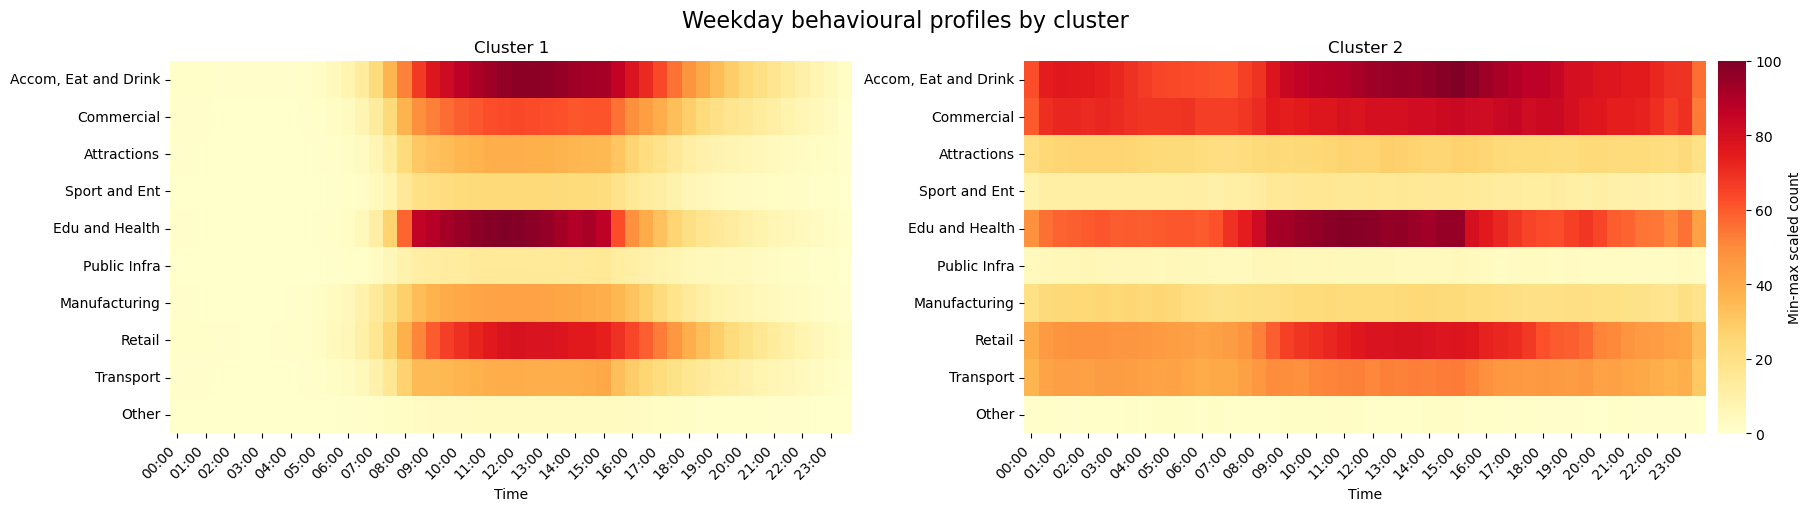

In [33]:
# Plot all non-noise weekday clusters in one figure and save it.
behavioural_profile_fig_dir = os.path.join(
    'pretrained_se_act_chain',
    f'{city}_{str_study_period}',
    'figures',
    'weekday_behavioural_profiles',
)
os.makedirs(behavioural_profile_fig_dir, exist_ok=True)

fig, axes = plot_cluster_behavioral_profile_subplots(
    df_stays_weekday_to_plot,
    normalisation='minmax',
    include_home=False,
    include_outliers=False,
    ncols=2,
    cmap='YlOrRd'
)
fig_path = os.path.join(behavioural_profile_fig_dir, f'weekday_behavioural_profiles_all_clusters_minmax.png')
fig.savefig(fig_path, dpi=400, bbox_inches='tight')
print(f'Saved weekday behavioural profile heatmap figure to: {fig_path}')

In [ ]:
# Interpretation